# V1 ATS Analyzer


In [40]:
!pip install PyPDF2 pandas numpy nltk


In [41]:
import PyPDF2
import pandas as pd
import numpy as np
import nltk

from IPython.display import display

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [42]:
skills_db=['python','java','sql','machine learning','tensorflow','pytorch','nlp']


In [43]:
skills_db = [

    "python",
    "java",
    "c",
    "c++",
    "sql",

    "machine learning",
    "deep learning",

    "tensorflow",
    "pytorch",

    "nlp",
    "bert",
    "huggingface",

    "aws",
    "docker",

    "git",
    "github",

    "linux",

    "pandas",
    "numpy",

    "scikit-learn",

    "opencv",

    "power bi",

    "excel",

    "data analysis",

    "data science"
]

In [44]:
def extract_text(pdf_path):

    text = ""

    with open(pdf_path, "rb") as file:

        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

In [45]:
import os

for file in os.listdir():
    print(file)

resumes
Sahil_Prakash_Resume_Updated (1).pdf
Sparsh_Tech_Resume (5).pdf
V1_ATS_Analyzer.ipynb
V2_Gemini_Analyzer.ipynb
V3_BERT_Semantic_Matching.ipynb
V4_Multi_Resume_Ranking.ipynb
venv


In [46]:
resume_path = "Sahil_Prakash_Resume.pdf"

In [47]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\admin\Downloads\resume checker
['resumes', 'Sahil_Prakash_Resume_Updated (1).pdf', 'Sparsh_Tech_Resume (5).pdf', 'V1_ATS_Analyzer.ipynb', 'V2_Gemini_Analyzer.ipynb', 'V3_BERT_Semantic_Matching.ipynb', 'V4_Multi_Resume_Ranking.ipynb', 'venv']


In [48]:
resume_path = "Sparsh_Tech_Resume (5).pdf"

resume_text = extract_text(resume_path)

print(resume_text[:2000])

Sparsh Gupta
Greater Noida, India
+91-9560362200 — sparsh8559@gmail.com
LinkedIn—GitHub
Professional Summary
Product-oriented mobile engineer with production React Native experience in BFSI and independently built Flut-
ter applications. Skilled in performance optimization, modular architectures, multilingual systems, and hardware
integrations.
Professional Experience
Go Digit General InsuranceBangalore, India
Trainee Developer – React NativeJuly 2025 – April 2026
- Architected and implemented multilingual support from scratch across the entire app, enabling Hindi, Kannada,
and Malayalam in addition to English using a custom i18n architecture in React Native CLI.
- Migrated Support flow (18–20 screens: CC tickets, RSA, SOS) and end-to-end Motor Insurance purchase flow (bike
and car) into independent micro-frontends, decoupling release cycles and enabling on-demand deployment.
- Led Android migration from React Native 0.72.14 to 0.81.6 across micro-frontend architecture withzero produc-

In [49]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills_db:

        if skill in text:

            found.append(skill)

    return sorted(
        list(
            set(found)
        )
    )

In [50]:
resume_skills = extract_skills(
    resume_text
)

print("Resume Skills:\n")

for skill in resume_skills:

    print("✓", skill)

Resume Skills:

✓ c
✓ c++
✓ git
✓ github
✓ java
✓ opencv
✓ python
✓ sql


In [51]:
job_description = """

Python Developer

Required Skills:

Python
SQL
Machine Learning
TensorFlow
AWS
Git
Docker

Good Communication Skills

"""

print(job_description)



Python Developer

Required Skills:

Python
SQL
Machine Learning
TensorFlow
AWS
Git
Docker

Good Communication Skills




In [52]:
jd_skills = extract_skills(
    job_description
)

print("JD Skills:\n")

for skill in jd_skills:

    print("✓", skill)

JD Skills:

✓ aws
✓ c
✓ docker
✓ git
✓ machine learning
✓ python
✓ sql
✓ tensorflow


In [53]:
matched_skills = list(
    set(resume_skills)
    &
    set(jd_skills)
)

missing_skills = list(
    set(jd_skills)
    -
    set(resume_skills)
)

if len(jd_skills) == 0:

    ats_score = 0

else:

    ats_score = (
        len(matched_skills)
        /
        len(jd_skills)
    ) * 100

ats_score = round(
    ats_score,
    2
)

In [54]:
print("="*50)

print(
    f"ATS SCORE : {ats_score}%"
)

print("="*50)

print("\nMATCHED SKILLS\n")

for skill in matched_skills:

    print("✓", skill)

print("\nMISSING SKILLS\n")

for skill in missing_skills:

    print("✗", skill)

ATS SCORE : 50.0%

MATCHED SKILLS

✓ git
✓ sql
✓ python
✓ c

MISSING SKILLS

✗ aws
✗ tensorflow
✗ docker
✗ machine learning


In [55]:
def generate_suggestions():

    suggestions = []

    if ats_score >= 80:

        suggestions.append(
            "Excellent ATS Match."
        )

    elif ats_score >= 60:

        suggestions.append(
            "Good ATS Match."
        )

    else:

        suggestions.append(
            "Resume needs improvement."
        )

    if len(missing_skills) > 0:

        suggestions.append(
            "Consider adding these skills if you have experience:"
        )

        for skill in missing_skills:

            suggestions.append(
                f"- {skill}"
            )

    return suggestions

In [56]:
suggestions = generate_suggestions()

print(
    "\nRESUME SUGGESTIONS\n"
)

for item in suggestions:

    print(item)


RESUME SUGGESTIONS

Resume needs improvement.
Consider adding these skills if you have experience:
- aws
- tensorflow
- docker
- machine learning


In [57]:
summary = pd.DataFrame({

    "Metric":[

        "ATS Score",
        "Resume Skills",
        "JD Skills",
        "Matched Skills",
        "Missing Skills"

    ],

    "Value":[

        ats_score,

        len(resume_skills),

        len(jd_skills),

        len(matched_skills),

        len(missing_skills)

    ]

})

display(summary)

,Metric,Value
0,ATS Score,50.0
1,Resume Skills,8.0
2,JD Skills,8.0
3,Matched Skills,4.0
4,Missing Skills,4.0


In [58]:
results = {

    "ATS Score":ats_score,

    "Resume Skills":resume_skills,

    "JD Skills":jd_skills,

    "Matched Skills":matched_skills,

    "Missing Skills":missing_skills

}

print(results)

{'ATS Score': 50.0, 'Resume Skills': ['c', 'c++', 'git', 'github', 'java', 'opencv', 'python', 'sql'], 'JD Skills': ['aws', 'c', 'docker', 'git', 'machine learning', 'python', 'sql', 'tensorflow'], 'Matched Skills': ['git', 'sql', 'python', 'c'], 'Missing Skills': ['aws', 'tensorflow', 'docker', 'machine learning']}


In [59]:
from sentence_transformers import SentenceTransformer

print("BERT Loaded")

BERT Loaded


In [60]:
!pip install sentence-transformers scikit-learn

In [61]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [62]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model Loaded")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7031.24it/s]


Model Loaded


In [63]:
resume_text = extract_text("Sahil_Prakash_Resume_Updated (1).pdf")

In [64]:
job_description = """
AI Engineer

Required Skills:

Python
Machine Learning
Deep Learning
PyTorch
TensorFlow
NLP
SQL
Git
AWS

"""

In [65]:
resume_embedding = model.encode(resume_text)

jd_embedding = model.encode(job_description)

In [66]:
resume_embedding = model.encode(
    resume_text
)

jd_embedding = model.encode(
    job_description
)

print("Embeddings Created")

Embeddings Created


In [67]:
score = cosine_similarity(
    [resume_embedding],
    [jd_embedding]
)[0][0]

print(f"Semantic Match Score: {score*100:.2f}%")

Semantic Match Score: 63.30%


In [68]:
semantic_score = score * 100

if semantic_score >= 80:
    print("🟢 Excellent Match")

elif semantic_score >= 60:
    print("🟡 Good Match")

else:
    print("🔴 Needs Improvement")

🟡 Good Match


In [69]:
print("="*50)
print("AI RESUME SCREENING REPORT")
print("="*50)

print(f"Semantic Match Score: {semantic_score:.2f}%")

if semantic_score >= 80:
    print("Recommendation: Shortlist Candidate")

elif semantic_score >= 60:
    print("Recommendation: Consider for Interview")

else:
    print("Recommendation: Reject")

AI RESUME SCREENING REPORT
Semantic Match Score: 63.30%
Recommendation: Consider for Interview


In [70]:
import os

print(os.listdir("resumes"))

['candidate1.pdf', 'candidate2.pdf']


In [71]:
import os

os.makedirs("resumes", exist_ok=True)

print("Folder created")

Folder created


In [72]:
print(os.listdir())

['resumes', 'Sahil_Prakash_Resume_Updated (1).pdf', 'Sparsh_Tech_Resume (5).pdf', 'V1_ATS_Analyzer.ipynb', 'V2_Gemini_Analyzer.ipynb', 'V3_BERT_Semantic_Matching.ipynb', 'V4_Multi_Resume_Ranking.ipynb', 'venv']


In [73]:
import os
import pandas as pd

In [74]:
job_description = """
AI Engineer

Python
Machine Learning
SQL
TensorFlow
PyTorch
Git
AWS
"""

In [75]:
import os
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

resume_folder = "resumes"
files = os.listdir(resume_folder)

results = []

for file in files:

    path = os.path.join(resume_folder, file)

    text = extract_text(path)

    resume_embedding = model.encode(text)

    jd_embedding = model.encode(job_description)

    score = cosine_similarity(
        [resume_embedding],
        [jd_embedding]
    )[0][0]

    results.append([
        file,
        round(score * 100, 2)
    ])

print("Scoring Complete")

Scoring Complete


In [76]:
df = pd.DataFrame(
    results,
    columns=[
        "Candidate",
        "Score"
    ]
)

df = df.sort_values(
    "Score",
    ascending=False
)

df

,Candidate,Score
1,candidate2.pdf,50.029999
0,candidate1.pdf,15.620000


In [77]:
winner = df.iloc[0]

print(
    f"Best Candidate: {winner['Candidate']}"
)

print(
    f"Score: {winner['Score']}%"
)

Best Candidate: candidate2.pdf
Score: 50.029998779296875%


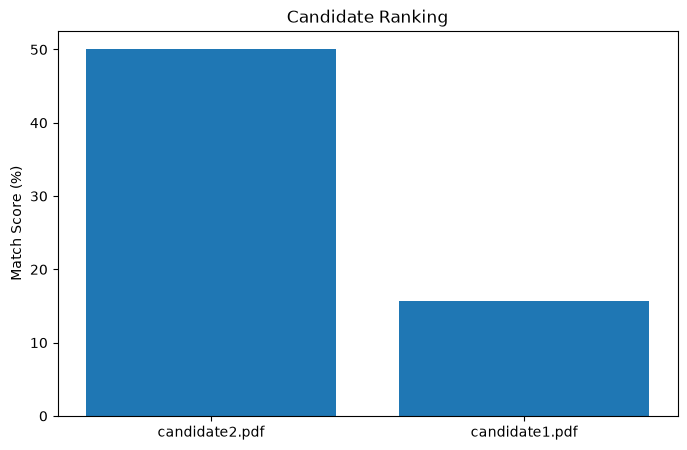

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["Candidate"],
    df["Score"]
)

plt.title("Candidate Ranking")
plt.ylabel("Match Score (%)")

plt.show()